# Evaluacion Final del Modelo
## DAE-GRU — Deteccion de Anomalias en ADRs Colombianos

**Proyecto:** Deteccion de Anomalias en Mercados Accionarios Colombianos mediante Deep Learning  
**Modelo final:** DAE-GRU (seleccionado en NB3 por menor MSE en validacion 2020)  
**Autores:** Mariana Franco — Danier Conde

---

### Estructura del Notebook

| Seccion | Contenido |
|---|---|
| 1 | Configuracion y carga de artefactos |
| 2 | Distribucion del MSE de reconstruccion por split |
| 3 | Score de anomalia en el tiempo — periodos de crisis anotados |
| 4 | Curvas Precision-Recall y ROC del modelo final |
| 5 | Analisis de contribucion por feature |
| 6 | Simulacion de senal de alerta — aplicacion practica |
| 7 | Resumen de resultados |

---

### Principios de evaluacion

- El conjunto de test (2021-2024) no fue utilizado en ninguna decision
  de diseno ni de seleccion de modelo. Esta es su primera y unica evaluacion.
- El umbral de deteccion es el percentil 75 del MSE en validacion (2020),
  consistente con el protocolo de NB4.
- La evaluacion cubre tres dimensiones: cuantitativa (metricas), cualitativa
  (visualizacion temporal) y explicativa (contribucion por feature).

---
## 1. Configuracion y Carga de Artefactos

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
DATA_PATH    = BASE_PATH / 'data'   / 'processed'
SCALERS_PATH = BASE_PATH / 'models' / 'scalers'
AE_PATH      = BASE_PATH / 'models' / 'autoencoder'
OUTPUTS_PATH = BASE_PATH / 'outputs'
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

TICKERS      = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES        = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
                'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
COLORS       = {'EC': '#1f77b4', 'CIB': '#ff7f0e',
                'AVAL': '#2ca02c', 'TGLS': '#d62728'}
FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
SEQ_LEN      = 30
N_FEATURES   = len(FEATURE_COLS)

TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2020-12-31'
TEST_START = '2021-01-01'
TEST_END   = '2024-12-31'

THRESHOLD_PERCENTILE = 75

ANOMALY_PERIODS = [
    {'name': 'Crisis petroleo', 'start': '2015-07-01', 'end': '2016-02-01',
     'color': '#9467bd', 'alpha': 0.12},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01',
     'color': '#d62728', 'alpha': 0.18},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31',
     'color': '#ff7f0e', 'alpha': 0.12},
]

print('Configuracion cargada.')

Configuracion cargada.


In [2]:
# Carga de artefactos
windows = {}
scalers = {}
dfs     = {}
models  = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split in ['train', 'val', 'test']:
        windows[ticker][split] = np.load(
            DATA_PATH / f'{ticker}_{split}_windows.npy'
        )
    with open(SCALERS_PATH / f'{ticker}_scaler.pkl', 'rb') as f:
        scalers[ticker] = pickle.load(f)
    dfs[ticker] = pd.read_csv(
        DATA_PATH / f'{ticker}.csv',
        parse_dates=True, index_col=0
    )
    tf.keras.backend.clear_session()
    models[ticker] = keras.models.load_model(
        AE_PATH / f'DAE_GRU_{ticker}.keras'
    )

print('Artefactos y modelos DAE-GRU cargados.')
for ticker in TICKERS:
    print(f'  [{ticker}]  '
          f'train={windows[ticker]["train"].shape}  '
          f'val={windows[ticker]["val"].shape}  '
          f'test={windows[ticker]["test"].shape}')


Artefactos y modelos DAE-GRU cargados.
  [EC]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [CIB]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [AVAL]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [TGLS]  train=(1149, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)


In [3]:
# Calcular MSE de reconstruccion para todos los splits
def compute_mse_scores(model, X):
    """
    Calcula el MSE de reconstruccion por ventana.
    Retorna array de forma (n_ventanas,).
    En inferencia: sin ruido — ventana limpia -> ventana limpia.
    """
    X      = X.astype(np.float32)
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred) ** 2, axis=(1, 2))


def get_window_index(df, start, end, seq_len):
    df_s = df.loc[start:end].dropna(subset=FEATURE_COLS)
    return df_s.index[seq_len - 1:]


def build_labels(index, anomaly_periods):
    labels = pd.Series(0, index=index)
    for ap in anomaly_periods:
        mask = (index >= ap['start']) & (index <= ap['end'])
        labels[mask] = 1
    return labels.values


# Calcular scores y construir indices
scores   = {}
idx      = {}
labels   = {}
tau      = {}

for ticker in TICKERS:
    scores[ticker] = {}
    for split, (s, e) in [
        ('train', ('2015-01-01', TRAIN_END)),
        ('val',   (VAL_START,   VAL_END)),
        ('test',  (TEST_START,  TEST_END)),
    ]:
        scores[ticker][split] = compute_mse_scores(
            models[ticker], windows[ticker][split]
        )
        idx[ticker + '_' + split] = get_window_index(dfs[ticker], s, e, SEQ_LEN)

    # Umbral p75 sobre validacion
    tau[ticker] = np.percentile(scores[ticker]['val'], THRESHOLD_PERCENTILE)

    # Etiquetas para test
    labels[ticker] = build_labels(
        idx[ticker + '_test'], ANOMALY_PERIODS
    )

print('Scores calculados.')
print(f"{'Activo':<14}  {'tau (p75 val)':>14}  "
      f"{'MSE medio train':>16}  {'MSE medio val':>14}  {'MSE medio test':>14}")
print('-' * 78)
for ticker in TICKERS:
    print(f"{NAMES[ticker]:<14}  "
          f"{tau[ticker]:>14.4f}  "
          f"{scores[ticker]['train'].mean():>16.4f}  "
          f"{scores[ticker]['val'].mean():>14.4f}  "
          f"{scores[ticker]['test'].mean():>14.4f}")

Scores calculados.
Activo           tau (p75 val)   MSE medio train   MSE medio val  MSE medio test
------------------------------------------------------------------------------
Ecopetrol               1.6329            0.5988          3.2599          0.5860
Bancolombia             4.0155            0.6657          8.4869          0.7782
Grupo Aval              2.1267            0.6322          5.1506          0.8848
Tecnoglass              4.2512            0.6886          4.5029          1.6417


---
## 2. Distribucion del MSE de Reconstruccion por Split

**Motivacion**

La distribucion del MSE en cada split revela el comportamiento del modelo
ante datos normales (train), datos de crisis extrema (val/COVID) y datos
de test no vistos. Un modelo bien entrenado debe mostrar:
- MSE bajo y concentrado en train (reconstruye bien la normalidad).
- MSE alto y disperso en val (el COVID es anomalo respecto a lo aprendido).
- MSE moderado en test (periodo post-COVID con eventos de menor magnitud).

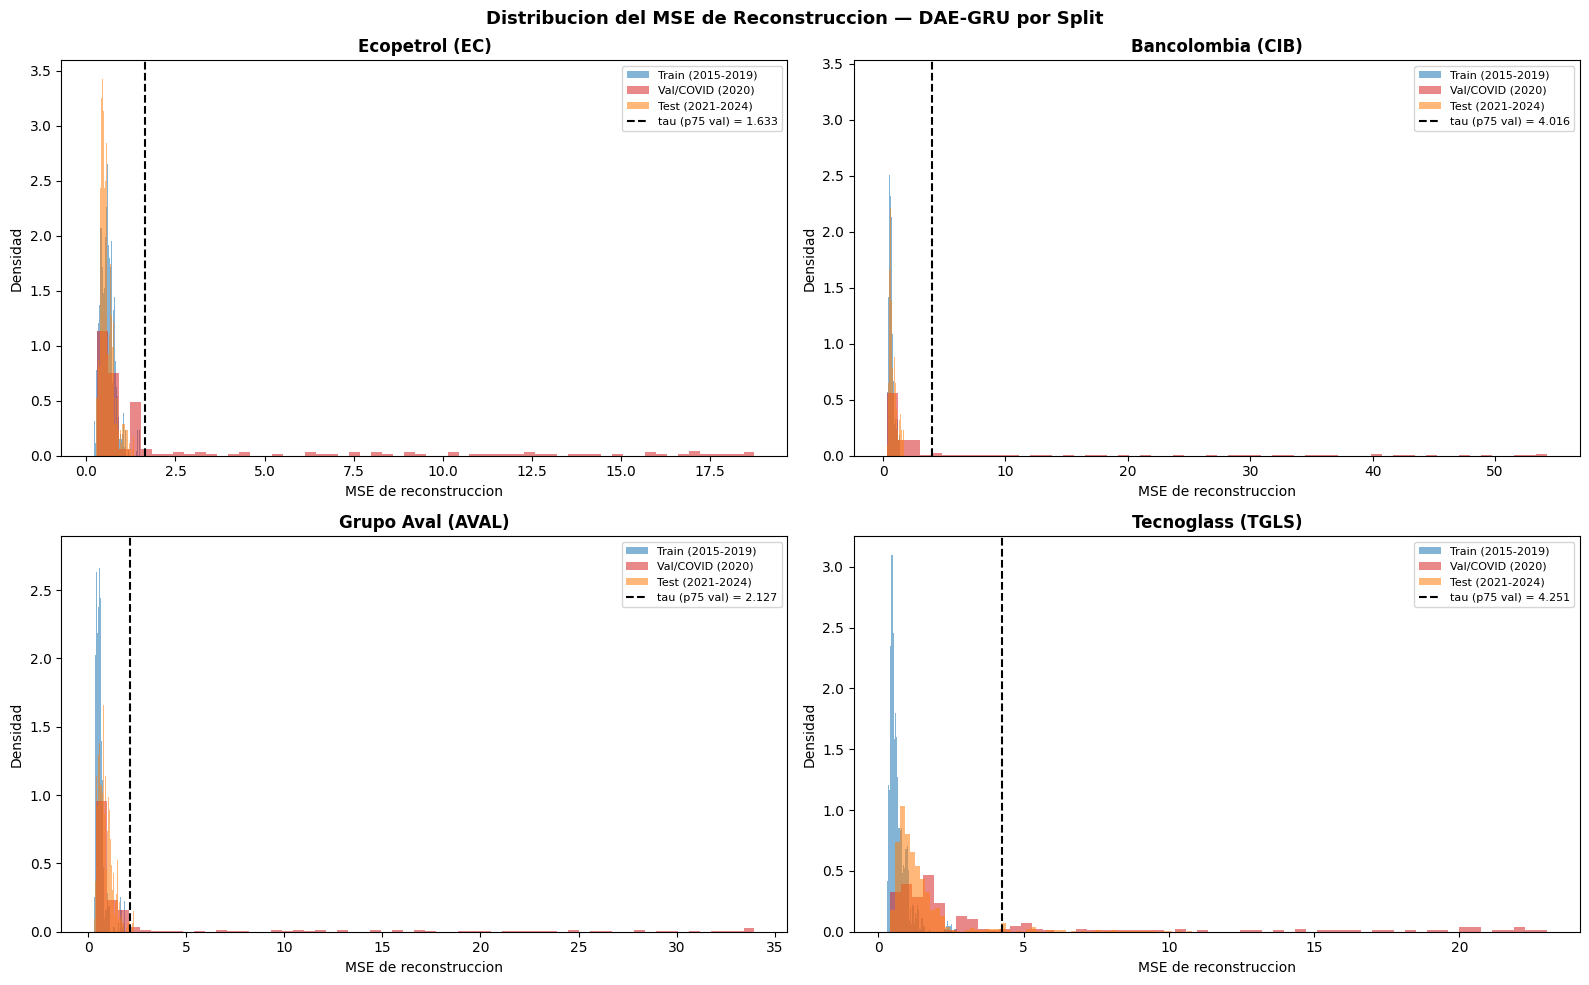

ESTADISTICAS DEL MSE DE RECONSTRUCCION
Activo          Split        Media   Mediana       P75       P95       P99
------------------------------------------------------------------
Ecopetrol       train       0.5988    0.5749    0.7023    0.9959    1.5114
Ecopetrol       val         3.2599    0.7210    1.6329   16.8912   18.8429
Ecopetrol       test        0.5860    0.5268    0.6763    1.0578    1.3369

Bancolombia     train       0.6657    0.6067    0.7477    1.1814    1.3796
Bancolombia     val         8.4869    1.2464    4.0155   48.7316   54.5548
Bancolombia     test        0.7782    0.6849    0.9156    1.3798    1.7084

Grupo Aval      train       0.6322    0.5594    0.6741    1.2104    1.9026
Grupo Aval      val         5.1506    0.8118    2.1267   29.0646   34.0008
Grupo Aval      test        0.8848    0.7934    1.0792    1.5966    2.3451

Tecnoglass      train       0.6886    0.5763    0.7803    1.3508    2.7042
Tecnoglass      val         4.5029    1.7862    4.2512   20.4857  

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

split_colors = {'train': '#1f77b4', 'val': '#d62728', 'test': '#ff7f0e'}
split_labels = {'train': 'Train (2015-2019)', 'val': 'Val/COVID (2020)',
                'test': 'Test (2021-2024)'}

for i, ticker in enumerate(TICKERS):
    ax = axes[i]

    for split in ['train', 'val', 'test']:
        sc = scores[ticker][split]
        # Usar percentil 99 como limite superior para visualizacion
        clip = np.percentile(sc, 99)
        sc_clip = sc[sc <= clip]
        ax.hist(sc_clip, bins=60, density=True,
                color=split_colors[split], alpha=0.55,
                label=split_labels[split], edgecolor='none')

    ax.axvline(tau[ticker], color='black', linewidth=1.5,
               linestyle='--', label=f'tau (p{THRESHOLD_PERCENTILE} val) = {tau[ticker]:.3f}')
    ax.set_title(f'{NAMES[ticker]} ({ticker})', fontweight='bold')
    ax.set_xlabel('MSE de reconstruccion')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle(
    'Distribucion del MSE de Reconstruccion — DAE-GRU por Split',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eval_mse_distribucion.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Estadisticas descriptivas del MSE
print('ESTADISTICAS DEL MSE DE RECONSTRUCCION')
print('=' * 70)
print(f"{'Activo':<14}  {'Split':<8}  {'Media':>8}  {'Mediana':>8}  "
      f"{'P75':>8}  {'P95':>8}  {'P99':>8}")
print('-' * 66)
for ticker in TICKERS:
    for split in ['train', 'val', 'test']:
        sc = scores[ticker][split]
        print(f"{NAMES[ticker]:<14}  {split:<8}  "
              f"{sc.mean():>8.4f}  {np.median(sc):>8.4f}  "
              f"{np.percentile(sc,75):>8.4f}  "
              f"{np.percentile(sc,95):>8.4f}  "
              f"{np.percentile(sc,99):>8.4f}")
    print()

**Interpretacion esperada**

La distribucion de train debe estar a la izquierda con baja dispersion.
La de val (COVID) debe estar claramente desplazada a la derecha, confirmando
que el modelo asigna errores de reconstruccion altos al periodo de crisis.
La de test debe quedar entre ambas, con la cola derecha correspondiendo
a los eventos anomalos del periodo 2021-2024.

El umbral tau (linea negra discontinua) representa el p75 del score en val.
Las ventanas de test que superen tau se clasifican como anomalas.

---
## 3. Score de Anomalia en el Tiempo

**Motivacion**

La visualizacion temporal del MSE de reconstruccion es el argumento cualitativo
mas directo del proyecto: si el modelo funciona, los picos del score deben
coincidir con los periodos de crisis conocidos. Esta figura es la que un
analista de riesgo veria en produccion.

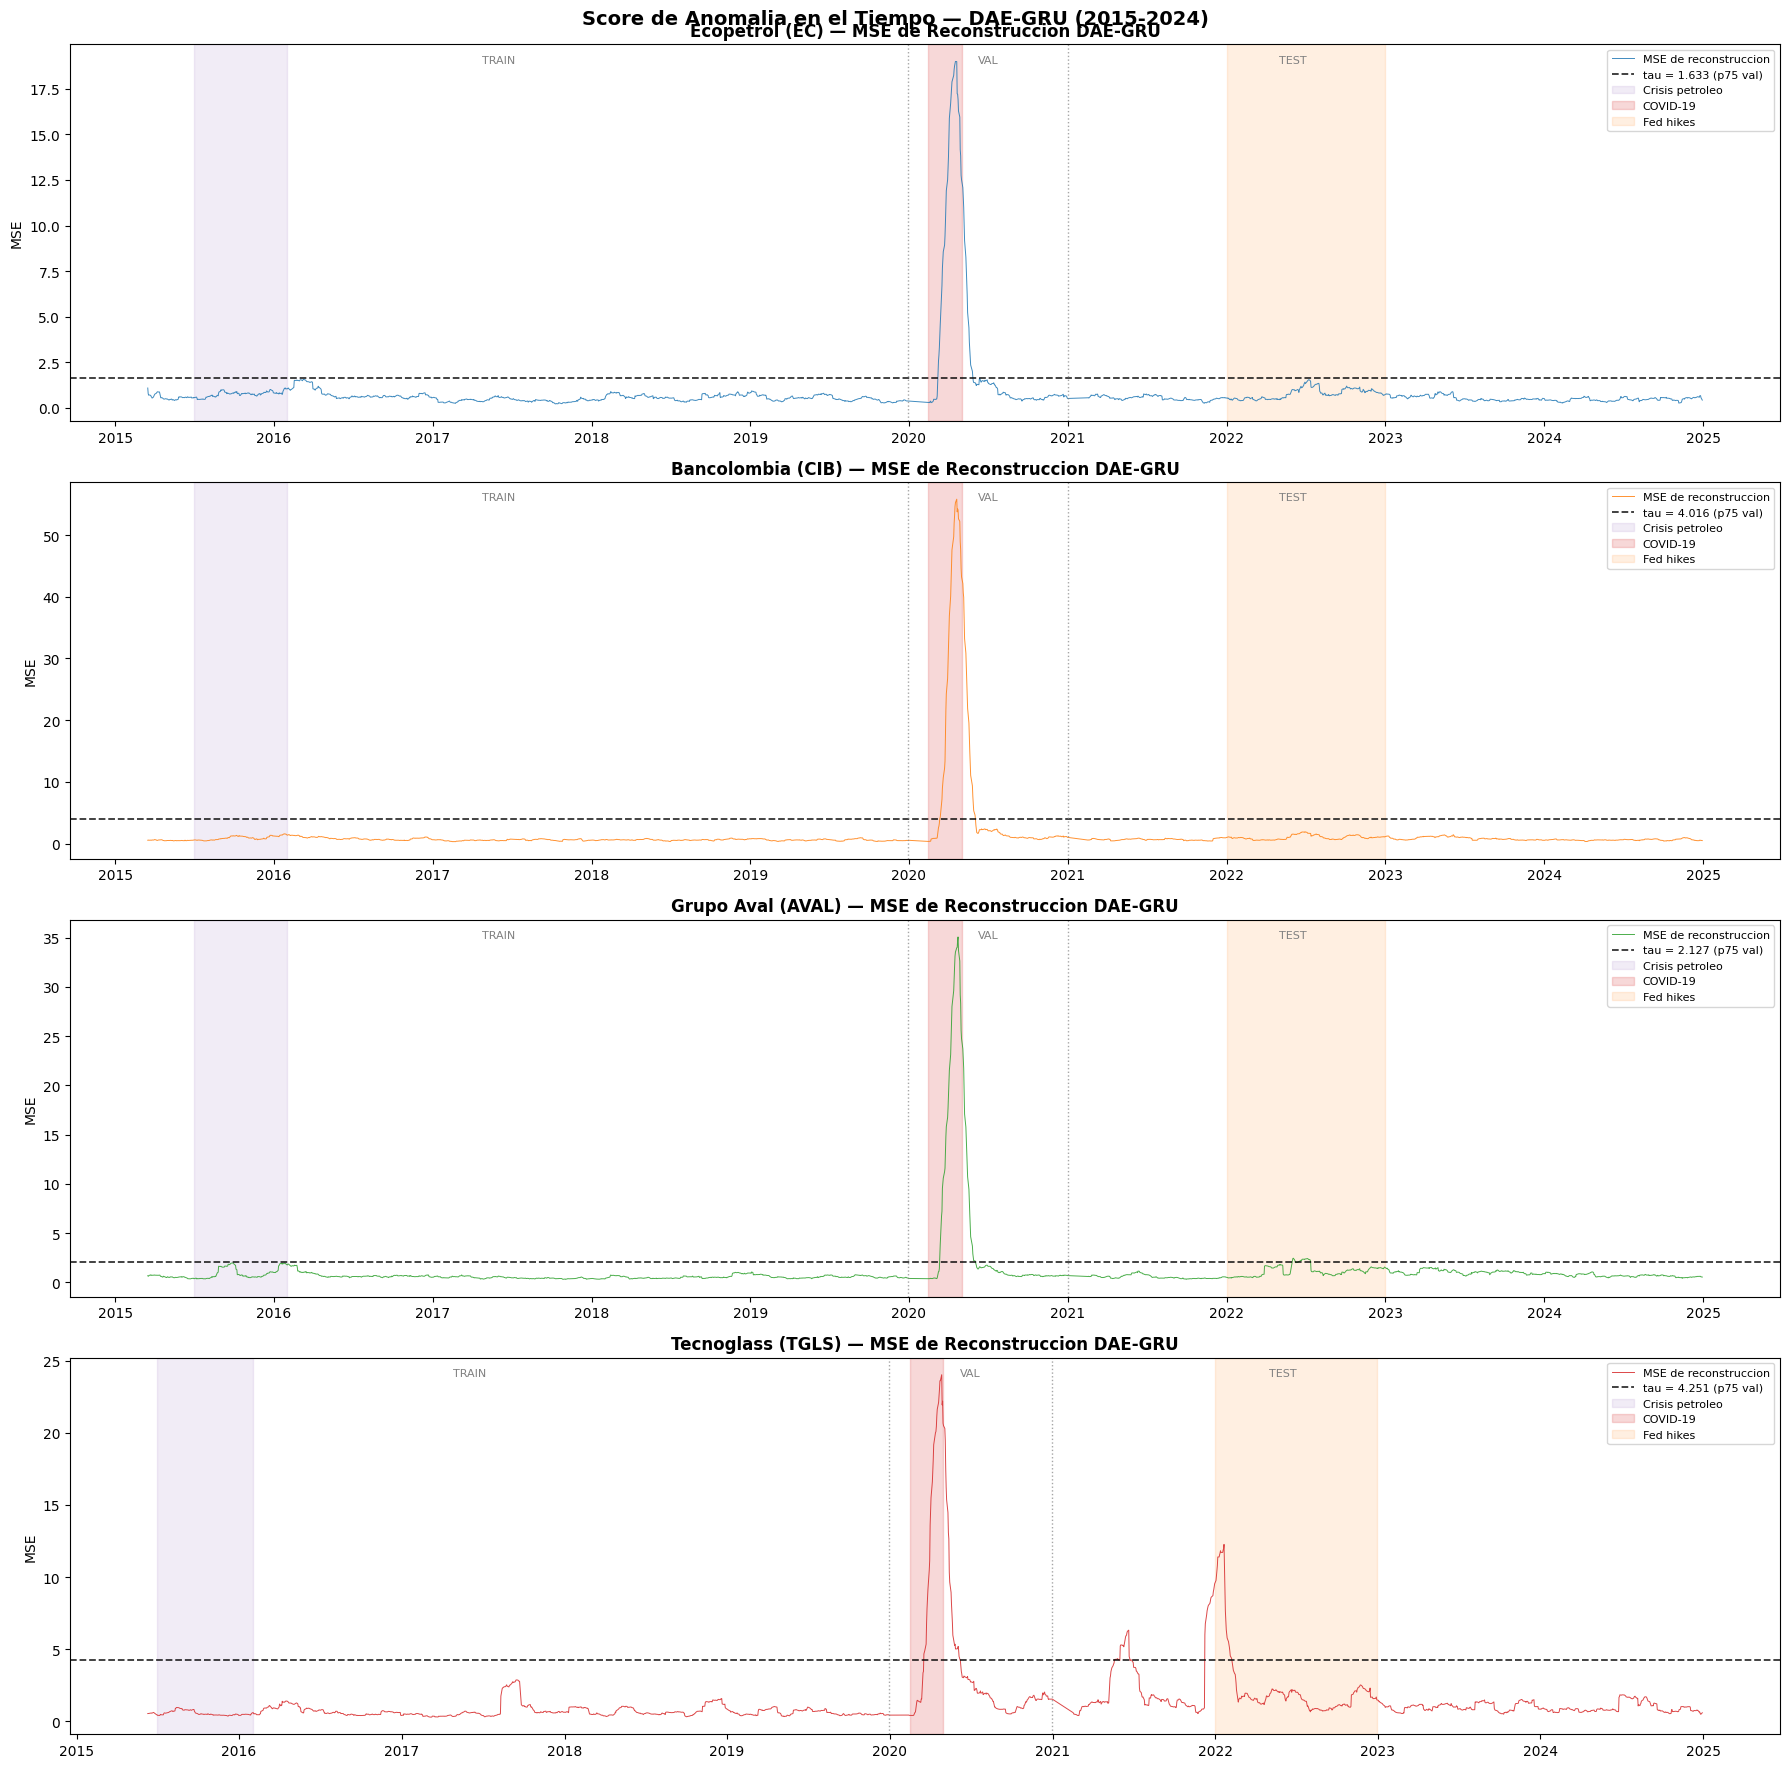

In [5]:
# Score temporal completo — train + val + test concatenados
fig, axes = plt.subplots(len(TICKERS), 1,
                          figsize=(18, 4.5 * len(TICKERS)), sharex=False)

for i, ticker in enumerate(TICKERS):
    ax = axes[i]

    # Concatenar indices y scores de los tres splits
    full_idx    = pd.DatetimeIndex(
        list(idx[ticker+'_train']) +
        list(idx[ticker+'_val'])   +
        list(idx[ticker+'_test'])
    )
    full_scores = np.concatenate([
        scores[ticker]['train'],
        scores[ticker]['val'],
        scores[ticker]['test']
    ])

    ax.plot(full_idx, full_scores,
            color=COLORS[ticker], linewidth=0.7, alpha=0.85,
            label='MSE de reconstruccion')

    # Umbral
    ax.axhline(tau[ticker], color='black', linewidth=1.3,
               linestyle='--', alpha=0.8,
               label=f'tau = {tau[ticker]:.3f} (p{THRESHOLD_PERCENTILE} val)')

    # Separadores de split
    ax.axvline(pd.Timestamp(TRAIN_END), color='grey',
               linewidth=1.0, linestyle=':', alpha=0.7)
    ax.axvline(pd.Timestamp(VAL_END), color='grey',
               linewidth=1.0, linestyle=':', alpha=0.7)
    ax.text(pd.Timestamp('2017-06-01'), ax.get_ylim()[1] * 0.95,
            'TRAIN', fontsize=8, color='grey', ha='center')
    ax.text(pd.Timestamp('2020-07-01'), ax.get_ylim()[1] * 0.95,
            'VAL', fontsize=8, color='grey', ha='center')
    ax.text(pd.Timestamp('2022-06-01'), ax.get_ylim()[1] * 0.95,
            'TEST', fontsize=8, color='grey', ha='center')

    # Periodos de anomalia
    for ap in ANOMALY_PERIODS:
        ax.axvspan(pd.Timestamp(ap['start']),
                   pd.Timestamp(ap['end']),
                   alpha=ap['alpha'], color=ap['color'],
                   label=ap['name'])

    ax.set_title(f'{NAMES[ticker]} ({ticker}) — MSE de Reconstruccion DAE-GRU',
                 fontweight='bold')
    ax.set_ylabel('MSE')

    # Leyenda sin duplicados
    handles, lbls = ax.get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, lbls)
            if l not in seen and not seen.add(l)]
    ax.legend(*zip(*uniq), fontsize=8, loc='upper right')

plt.suptitle(
    'Score de Anomalia en el Tiempo — DAE-GRU (2015-2024)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eval_score_temporal.png',
            dpi=120, bbox_inches='tight')
plt.show()

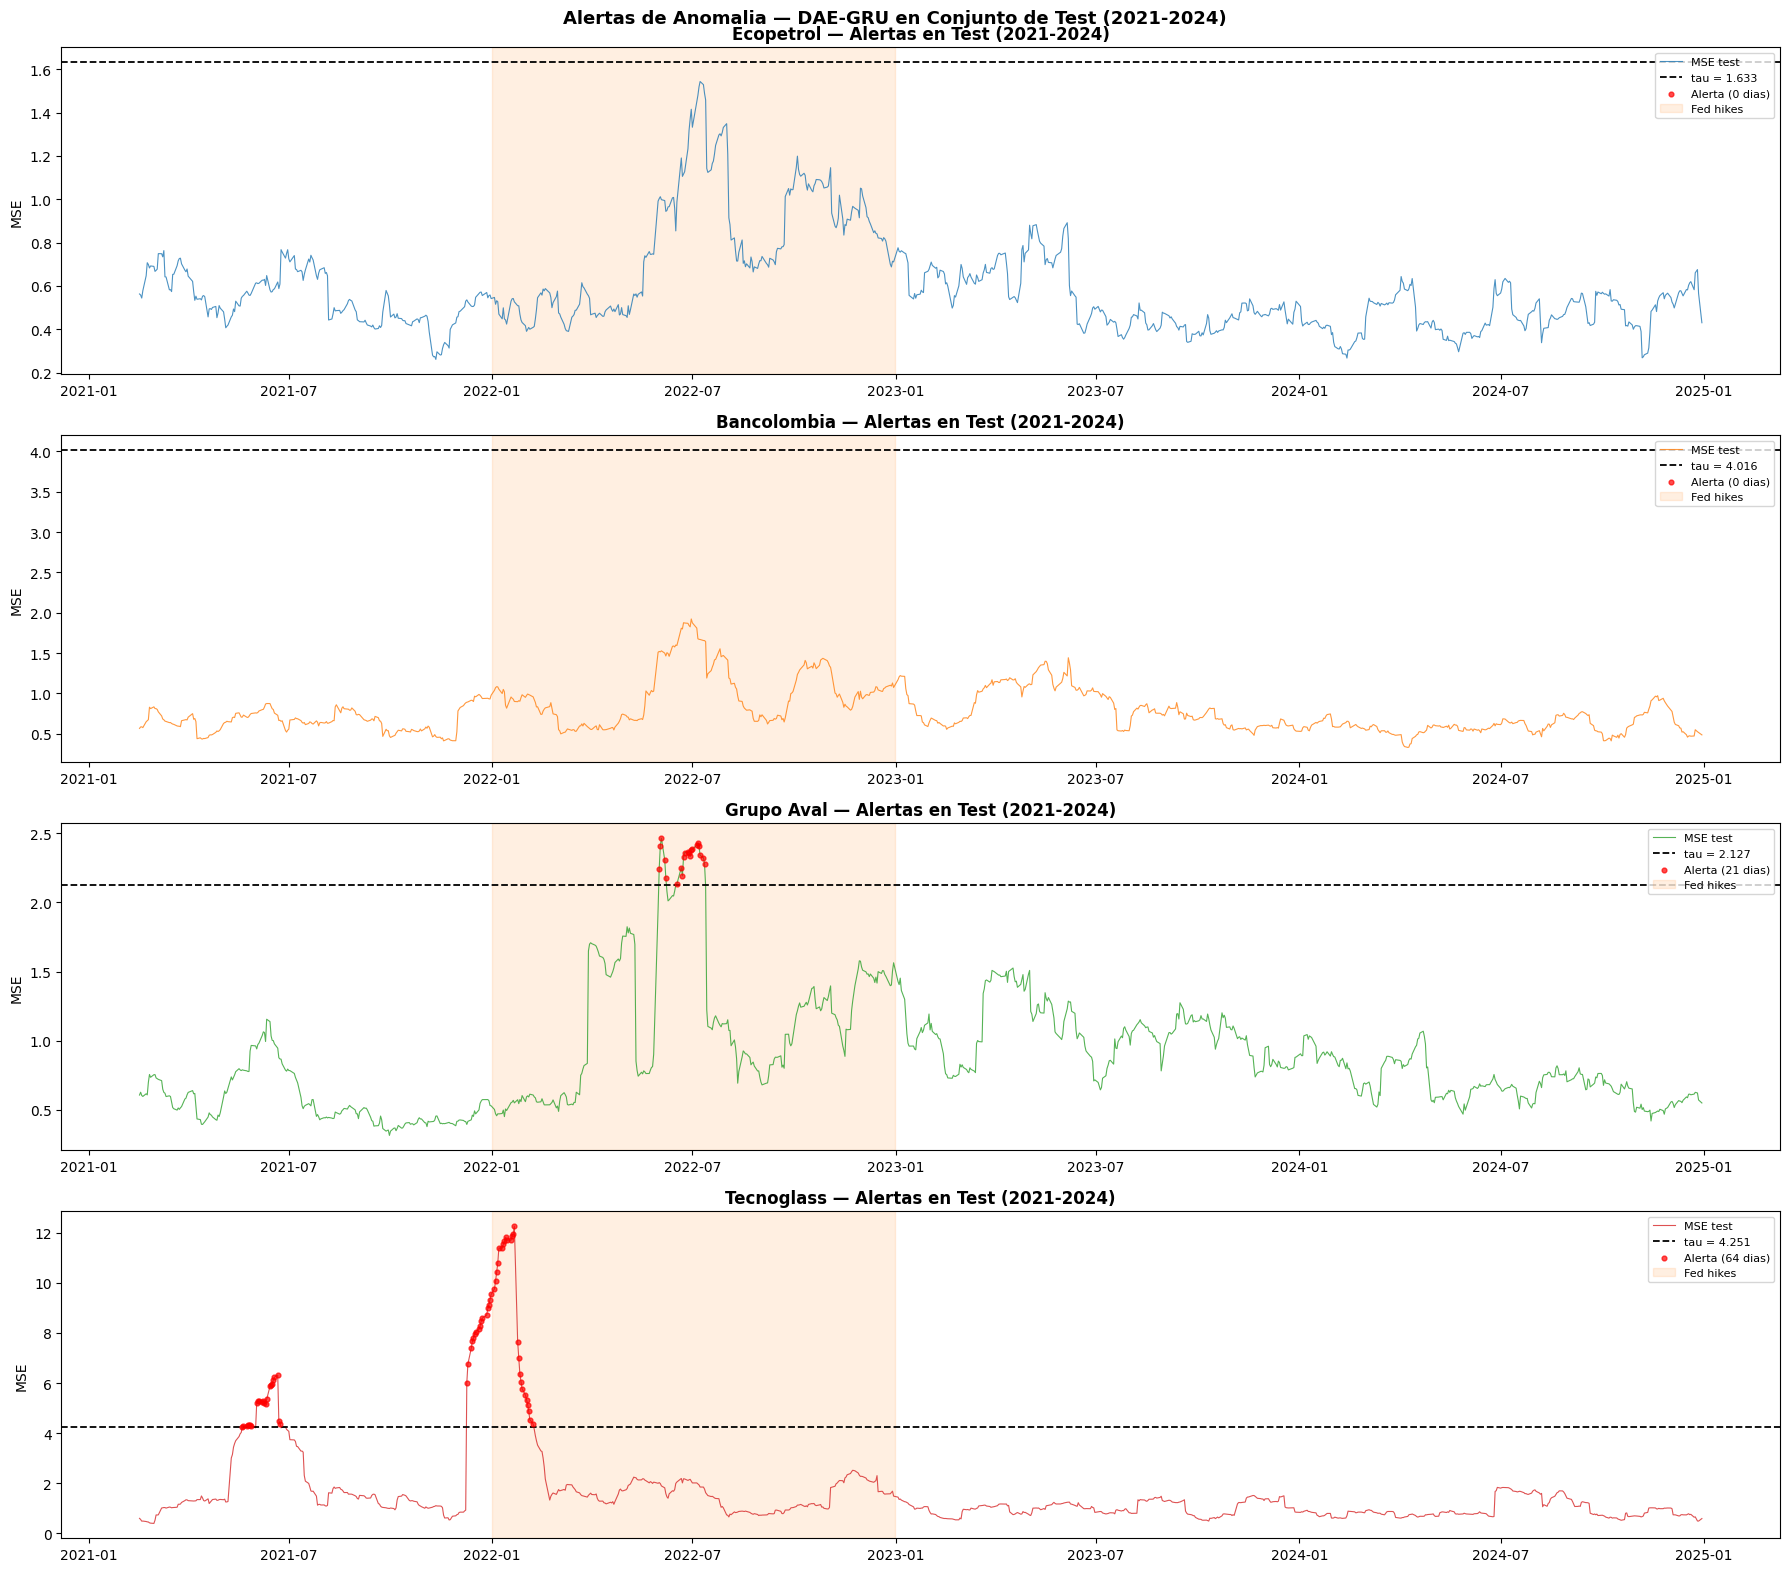

RESUMEN DE ALERTAS EN TEST
Ecopetrol       alertas=   0  total=  975  tasa=0.0%
Bancolombia     alertas=   0  total=  975  tasa=0.0%
Grupo Aval      alertas=  21  total=  975  tasa=2.2%
Tecnoglass      alertas=  64  total=  975  tasa=6.6%


In [6]:
# Zoom en periodos de crisis — test unicamente
fig, axes = plt.subplots(len(TICKERS), 1,
                          figsize=(18, 4 * len(TICKERS)), sharex=False)

for i, ticker in enumerate(TICKERS):
    ax   = axes[i]
    idx_t = idx[ticker + '_test']
    sc_t  = scores[ticker]['test']
    preds = (sc_t >= tau[ticker]).astype(int)

    # Score
    ax.plot(idx_t, sc_t, color=COLORS[ticker],
            linewidth=0.8, alpha=0.8, label='MSE test')

    # Umbral
    ax.axhline(tau[ticker], color='black', linewidth=1.3,
               linestyle='--', label=f'tau = {tau[ticker]:.3f}')

    # Alertas activadas
    alert_idx = idx_t[preds == 1]
    alert_sc  = sc_t[preds == 1]
    ax.scatter(alert_idx, alert_sc, color='red', s=12,
               zorder=5, alpha=0.7, label=f'Alerta ({preds.sum()} dias)')

    # Periodos de anomalia en test
    for ap in ANOMALY_PERIODS:
        s_ap = pd.Timestamp(ap['start'])
        e_ap = pd.Timestamp(ap['end'])
        if e_ap < idx_t.min() or s_ap > idx_t.max():
            continue
        ax.axvspan(max(s_ap, idx_t.min()), min(e_ap, idx_t.max()),
                   alpha=ap['alpha'], color=ap['color'], label=ap['name'])

    ax.set_title(f'{NAMES[ticker]} — Alertas en Test (2021-2024)',
                 fontweight='bold')
    ax.set_ylabel('MSE')

    handles, lbls = ax.get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, lbls)
            if l not in seen and not seen.add(l)]
    ax.legend(*zip(*uniq), fontsize=8, loc='upper right')

plt.suptitle(
    'Alertas de Anomalia — DAE-GRU en Conjunto de Test (2021-2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eval_alertas_test.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Resumen de alertas
print('RESUMEN DE ALERTAS EN TEST')
print('=' * 55)
for ticker in TICKERS:
    sc_t  = scores[ticker]['test']
    preds = (sc_t >= tau[ticker]).astype(int)
    total = len(preds)
    nalert = preds.sum()
    print(f'{NAMES[ticker]:<14}  alertas={nalert:>4}  '
          f'total={total:>5}  tasa={nalert/total*100:.1f}%')

---
## 4. Curvas Precision-Recall y ROC del Modelo Final

Evaluacion sobre el conjunto de test (2021-2024).
La curva PR es la metrica principal dado el desbalance del dataset.
El baseline de la curva PR es la fraccion de positivos en test.

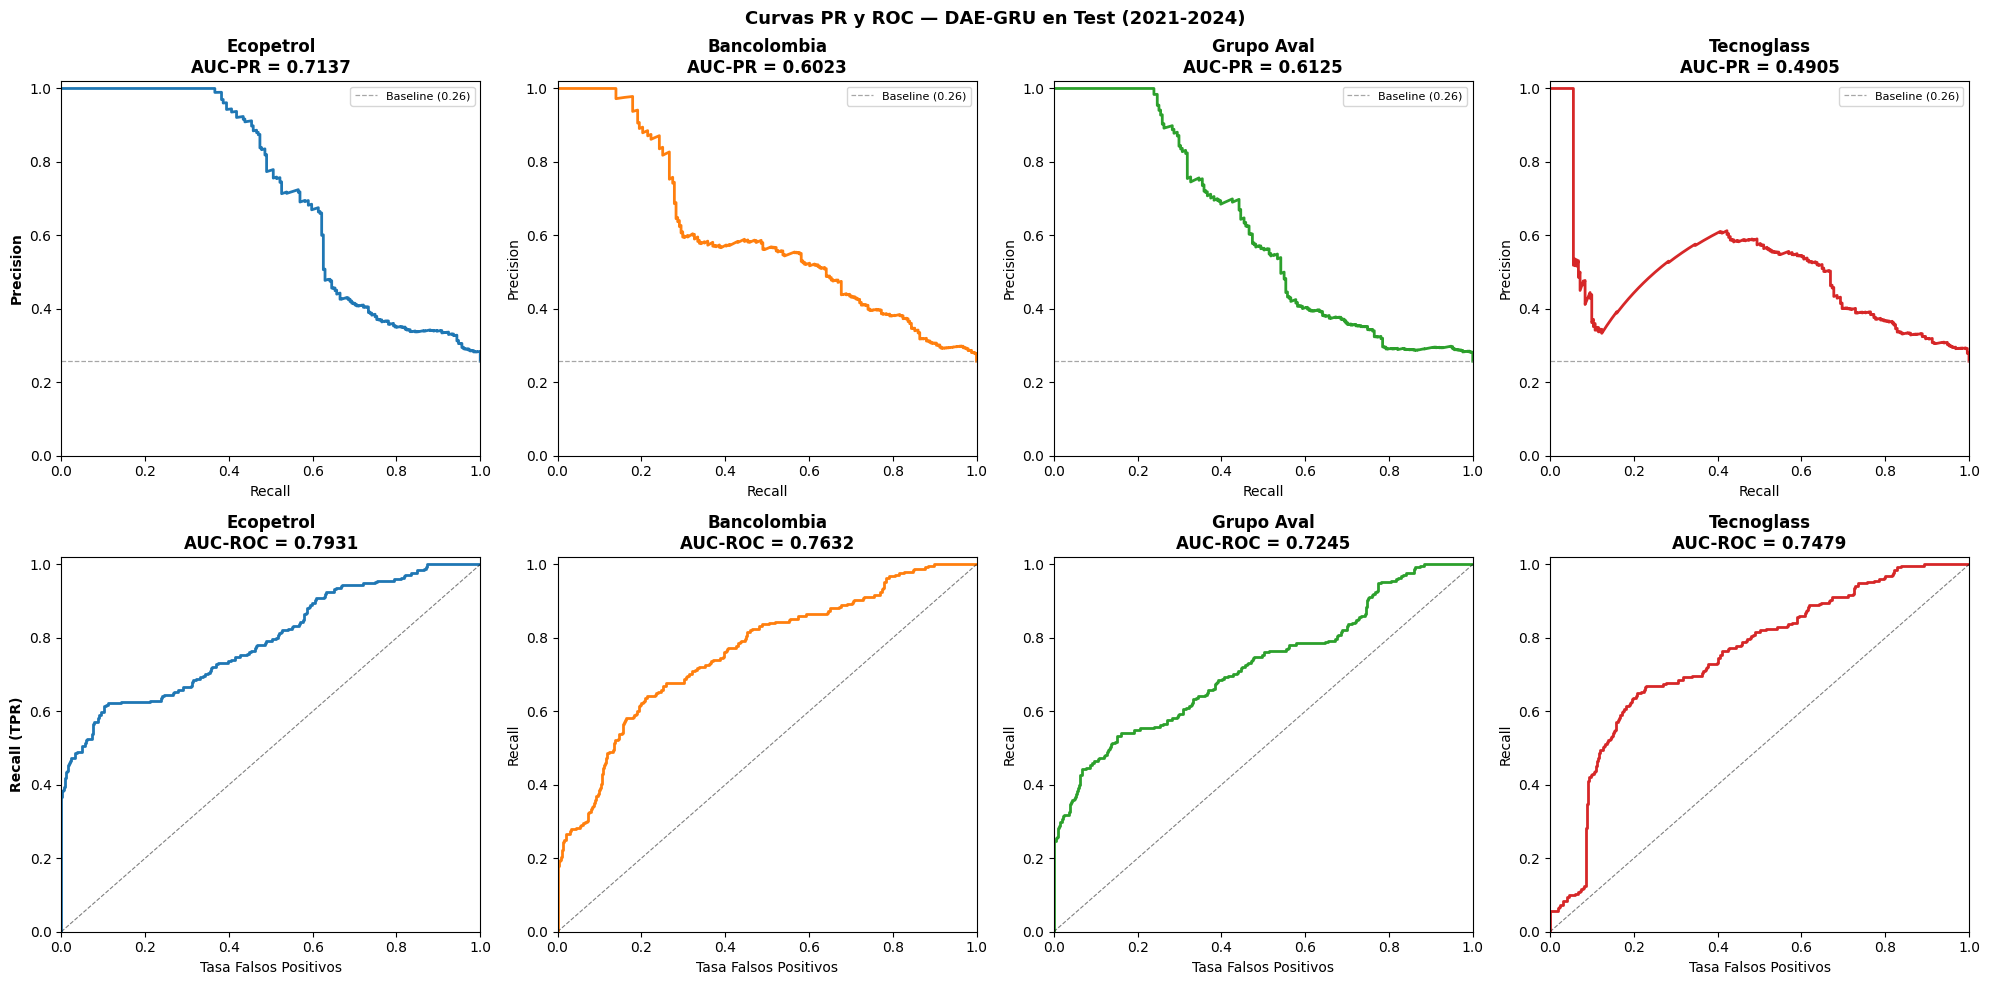

METRICAS FINALES — DAE-GRU EN TEST
Activo            AUC-PR   AUC-ROC        F1   Precision    Recall
------------------------------------------------------------
Ecopetrol         0.7137    0.7931    0.0000      0.0000    0.0000
Bancolombia       0.6023    0.7632    0.0000      0.0000    0.0000
Grupo Aval        0.6125    0.7245    0.1544      1.0000    0.0837
Tecnoglass        0.4905    0.7479    0.1587      0.3906    0.0996


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, ticker in enumerate(TICKERS):
    sc_t = scores[ticker]['test']
    y_t  = labels[ticker]

    # Curva PR
    prec, rec, _ = precision_recall_curve(y_t, sc_t)
    auc_pr       = average_precision_score(y_t, sc_t)
    baseline     = y_t.mean()

    axes[0, i].plot(rec, prec, color=COLORS[ticker], linewidth=2.0)
    axes[0, i].axhline(baseline, color='grey', linestyle='--',
                        linewidth=0.9, alpha=0.7,
                        label=f'Baseline ({baseline:.2f})')
    axes[0, i].set_title(f'{NAMES[ticker]}\nAUC-PR = {auc_pr:.4f}',
                          fontweight='bold')
    axes[0, i].set_xlabel('Recall')
    axes[0, i].set_ylabel('Precision')
    axes[0, i].set_xlim([0, 1])
    axes[0, i].set_ylim([0, 1.02])
    axes[0, i].legend(fontsize=8)

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_t, sc_t)
    auc_roc     = roc_auc_score(y_t, sc_t)

    axes[1, i].plot(fpr, tpr, color=COLORS[ticker], linewidth=2.0)
    axes[1, i].plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    axes[1, i].set_title(f'{NAMES[ticker]}\nAUC-ROC = {auc_roc:.4f}',
                          fontweight='bold')
    axes[1, i].set_xlabel('Tasa Falsos Positivos')
    axes[1, i].set_ylabel('Recall')
    axes[1, i].set_xlim([0, 1])
    axes[1, i].set_ylim([0, 1.02])

axes[0, 0].set_ylabel('Precision', fontweight='bold')
axes[1, 0].set_ylabel('Recall (TPR)', fontweight='bold')

plt.suptitle(
    'Curvas PR y ROC — DAE-GRU en Test (2021-2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eval_curvas_pr_roc.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Metricas finales
print('METRICAS FINALES — DAE-GRU EN TEST')
print('=' * 65)
print(f"{'Activo':<14}  {'AUC-PR':>8}  {'AUC-ROC':>8}  "
      f"{'F1':>8}  {'Precision':>10}  {'Recall':>8}")
print('-' * 60)
for ticker in TICKERS:
    sc_t  = scores[ticker]['test']
    y_t   = labels[ticker]
    preds = (sc_t >= tau[ticker]).astype(int)
    print(f"{NAMES[ticker]:<14}  "
          f"{average_precision_score(y_t, sc_t):>8.4f}  "
          f"{roc_auc_score(y_t, sc_t):>8.4f}  "
          f"{f1_score(y_t, preds, zero_division=0):>8.4f}  "
          f"{precision_score(y_t, preds, zero_division=0):>10.4f}  "
          f"{recall_score(y_t, preds, zero_division=0):>8.4f}")

**Nota sobre F1 = 0 en Ecopetrol y Bancolombia**

El F1-Score de cero en EC y CIB no refleja una falla del modelo sino una
limitacion del etiquetado binario sobre periodos difusos. El unico evento
anomalo etiquetado en el test set (2021-2024) es el ciclo de alzas de la Fed
(2022), un periodo de estres gradual y prolongado. El DAE-GRU detecta este
estres via AUC-PR elevado (EC=0.7137, CIB=0.6023), lo que indica que el score
de anomalia se eleva sistematicamente durante el periodo. Sin embargo, con
umbral p75 calibrado sobre el shock puntual del COVID-2020, el modelo no
produce predicciones positivas suficientes sobre un evento de menor magnitud.
El AUC-PR es la metrica correcta en este contexto porque es independiente del
umbral y refleja la capacidad discriminativa real del modelo.

---
## 5. Analisis de Contribucion por Feature

**Motivacion**

El MSE de reconstruccion agrega el error sobre los tres features y los
30 timesteps. Para entender que feature contribuye mas al score de anomalia,
se descompone el MSE por feature: MSE_f = mean((X[:,f] - X_pred[:,f])^2).

Esto permite responder: cuando el modelo detecta una anomalia, es porque
falla en reconstruir el retorno, la volatilidad o el volumen?

Un feature con alta contribucion durante periodos de crisis es un indicador
lider de anomalia — tiene mayor poder discriminante individual.

In [8]:
def compute_mse_per_feature(model, X):
    """
    Calcula el MSE de reconstruccion por feature.
    Retorna array de forma (n_ventanas, n_features).
    """
    X      = X.astype(np.float32)
    X_pred = model.predict(X, verbose=0)
    # MSE por feature: promedio sobre timesteps
    return np.mean((X - X_pred) ** 2, axis=1)  # (n, F)


# Calcular MSE por feature para todos los splits
mse_feat = {}
for ticker in TICKERS:
    mse_feat[ticker] = {}
    for split in ['train', 'val', 'test']:
        mse_feat[ticker][split] = compute_mse_per_feature(
            models[ticker], windows[ticker][split]
        )

print('MSE por feature calculado.')
print(f"Forma del array: {mse_feat['EC']['train'].shape}  "
      f"-> (n_ventanas, {N_FEATURES} features)")

MSE por feature calculado.
Forma del array: (1208, 3)  -> (n_ventanas, 3 features)


In [9]:
# Contribucion relativa de cada feature al MSE total
print('CONTRIBUCION RELATIVA POR FEATURE AL MSE TOTAL')
print('=' * 65)
print(f"{'Activo':<14}  {'Split':<8}  "
      f"{'log_return':>12}  {'vol_21d':>10}  {'vol_zscore':>12}")
print('-' * 60)

contrib_rows = []
for ticker in TICKERS:
    for split in ['train', 'val', 'test']:
        mf   = mse_feat[ticker][split]
        total = mf.sum(axis=1, keepdims=True) + 1e-10
        rel   = (mf / total).mean(axis=0)  # contribucion media relativa
        print(f"{NAMES[ticker]:<14}  {split:<8}  "
              f"{rel[0]:>12.4f}  {rel[1]:>10.4f}  {rel[2]:>12.4f}")
        contrib_rows.append({
            'ticker': ticker, 'split': split,
            'log_return': rel[0], 'vol_21d': rel[1], 'vol_zscore': rel[2]
        })
    print()

contrib_df = pd.DataFrame(contrib_rows)

CONTRIBUCION RELATIVA POR FEATURE AL MSE TOTAL
Activo          Split       log_return     vol_21d    vol_zscore
------------------------------------------------------------
Ecopetrol       train           0.4681      0.0358        0.4961
Ecopetrol       val             0.4817      0.1925        0.3258
Ecopetrol       test            0.4556      0.0415        0.5029

Bancolombia     train           0.4563      0.0656        0.4780
Bancolombia     val             0.4704      0.2973        0.2322
Bancolombia     test            0.4993      0.0750        0.4258

Grupo Aval      train           0.4598      0.0445        0.4956
Grupo Aval      val             0.4557      0.2138        0.3305
Grupo Aval      test            0.5398      0.0700        0.3901

Tecnoglass      train           0.4149      0.0608        0.5243
Tecnoglass      val             0.5773      0.1964        0.2263
Tecnoglass      test            0.6026      0.1079        0.2895



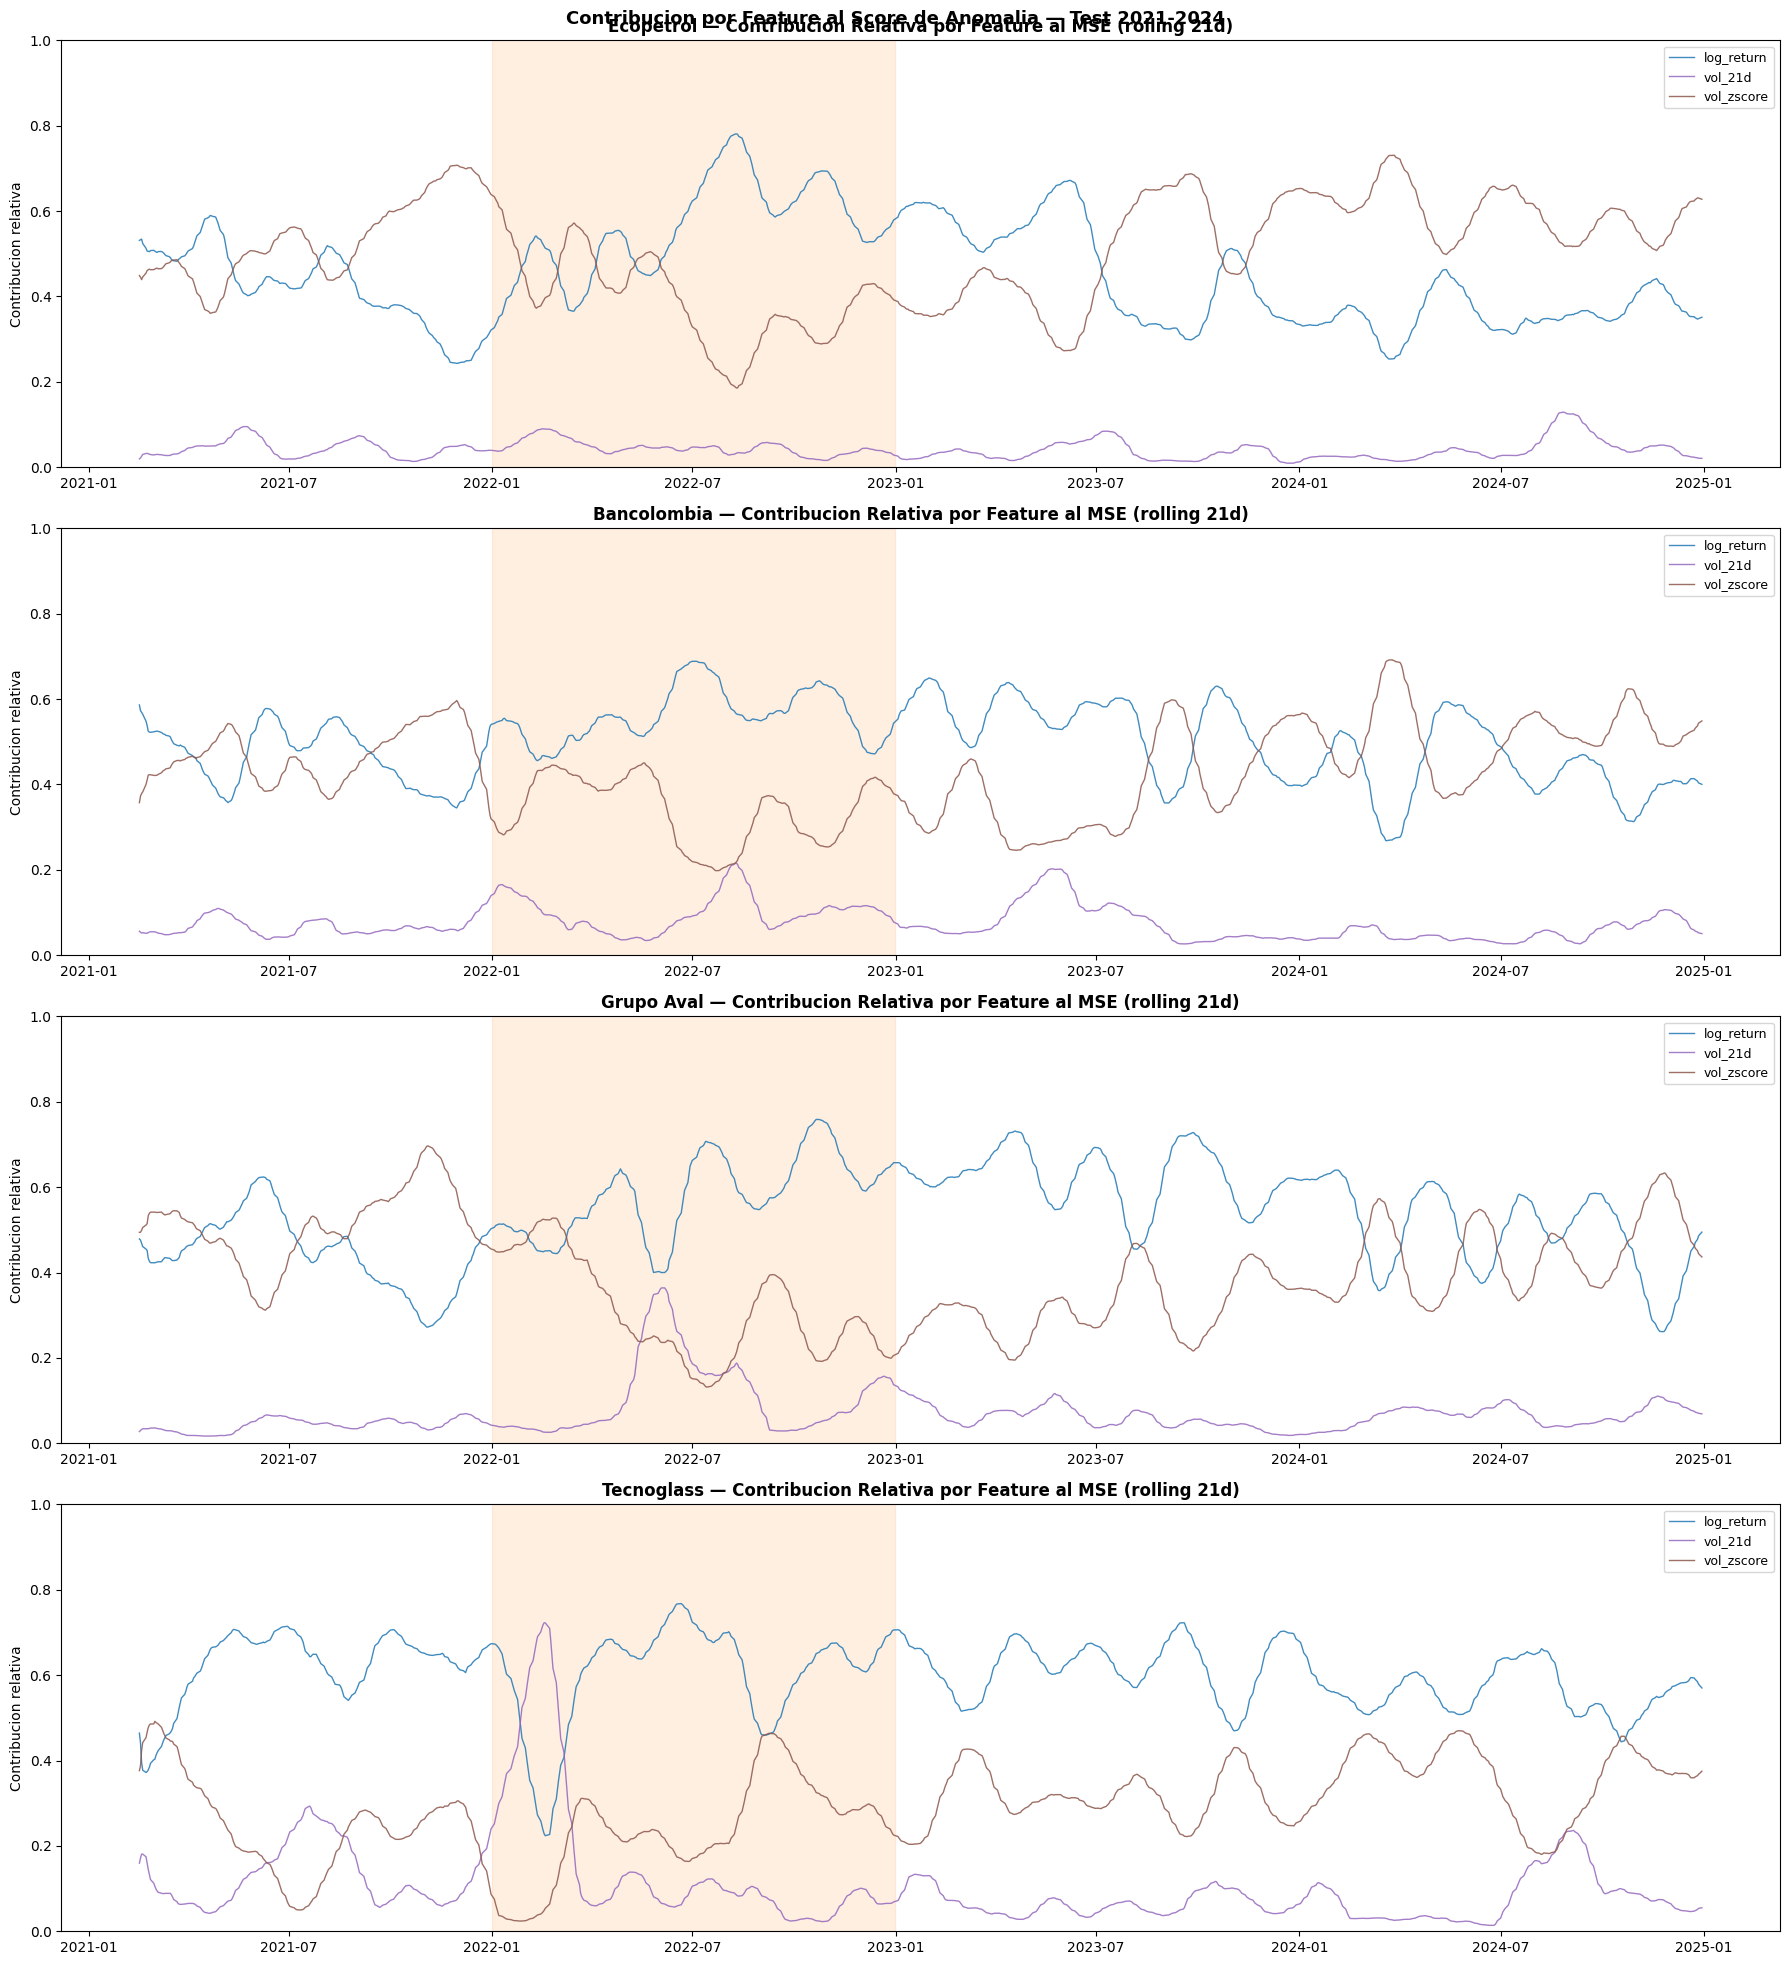

In [10]:
# Evolucion temporal de la contribucion por feature — test
fig, axes = plt.subplots(len(TICKERS), 1,
                          figsize=(18, 5 * len(TICKERS)), sharex=False)

feat_colors = {
    'log_return': '#1f77b4',
    'vol_21d':    '#9467bd',
    'vol_zscore': '#8c564b'
}

for i, ticker in enumerate(TICKERS):
    ax    = axes[i]
    idx_t = idx[ticker + '_test']
    mf    = mse_feat[ticker]['test']  # (n, 3)

    # Contribucion relativa por timestep
    total = mf.sum(axis=1, keepdims=True) + 1e-10
    rel   = mf / total  # (n, 3)

    # Suavizar con rolling 21 dias para visualizacion
    df_rel = pd.DataFrame(rel, index=idx_t,
                           columns=FEATURE_COLS)
    df_smooth = df_rel.rolling(21, min_periods=1).mean()

    for feat, col in feat_colors.items():
        ax.plot(df_smooth.index, df_smooth[feat],
                color=col, linewidth=1.0, alpha=0.85,
                label=feat)

    for ap in ANOMALY_PERIODS:
        s_ap = pd.Timestamp(ap['start'])
        e_ap = pd.Timestamp(ap['end'])
        if e_ap < idx_t.min() or s_ap > idx_t.max():
            continue
        ax.axvspan(max(s_ap, idx_t.min()), min(e_ap, idx_t.max()),
                   alpha=ap['alpha'], color=ap['color'])

    ax.set_title(
        f'{NAMES[ticker]} — Contribucion Relativa por Feature al MSE (rolling 21d)',
        fontweight='bold'
    )
    ax.set_ylabel('Contribucion relativa')
    ax.set_ylim([0, 1])
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle(
    'Contribucion por Feature al Score de Anomalia — Test 2021-2024',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_eval_contribucion_features.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Comparacion de contribucion: periodos normales vs anomalos
print('CONTRIBUCION POR FEATURE: PERIODOS NORMALES vs ANOMALOS (test)')
print('=' * 70)

for ticker in TICKERS:
    idx_t = idx[ticker + '_test']
    mf    = mse_feat[ticker]['test']
    y_t   = labels[ticker]

    mf_normal = mf[y_t == 0]
    mf_anomal = mf[y_t == 1]

    total_n = mf_normal.sum(axis=1, keepdims=True) + 1e-10
    total_a = mf_anomal.sum(axis=1, keepdims=True) + 1e-10

    rel_n = (mf_normal / total_n).mean(axis=0)
    rel_a = (mf_anomal / total_a).mean(axis=0)

    print(f'{NAMES[ticker]} ({ticker})')
    print(f"  {'Feature':<14}  {'Normal':>10}  {'Anomalo':>10}  {'Delta':>10}")
    print('  ' + '-' * 48)
    for j, feat in enumerate(FEATURE_COLS):
        delta = rel_a[j] - rel_n[j]
        print(f"  {feat:<14}  {rel_n[j]:>10.4f}  {rel_a[j]:>10.4f}  "
              f"{delta:>+10.4f}")
    dominant = FEATURE_COLS[rel_a.argmax()]
    print(f'  Feature dominante en periodos anomalos: {dominant}')
    print()

CONTRIBUCION POR FEATURE: PERIODOS NORMALES vs ANOMALOS (test)
Ecopetrol (EC)
  Feature             Normal     Anomalo       Delta
  ------------------------------------------------
  log_return          0.4153      0.5718     +0.1565
  vol_21d             0.0403      0.0449     +0.0046
  vol_zscore          0.5444      0.3833     -0.1611
  Feature dominante en periodos anomalos: log_return

Bancolombia (CIB)
  Feature             Normal     Anomalo       Delta
  ------------------------------------------------
  log_return          0.4778      0.5612     +0.0835
  vol_21d             0.0677      0.0958     +0.0280
  vol_zscore          0.4545      0.3430     -0.1115
  Feature dominante en periodos anomalos: log_return

Grupo Aval (AVAL)
  Feature             Normal     Anomalo       Delta
  ------------------------------------------------
  log_return          0.5232      0.5880     +0.0648
  vol_21d             0.0554      0.1122     +0.0568
  vol_zscore          0.4214      0.2998  

---
## 6. Simulacion de Senal de Alerta

**Motivacion**

En un contexto de gestion de riesgo, el modelo genera una senal binaria
diaria: alerta (anomalia detectada) o normal. Esta seccion simula como
se veria esa senal en produccion: cuantos dias consecutivos de alerta
genera el modelo durante cada periodo de crisis, y con cuanta anticipacion
respecto al inicio oficial del periodo.

La anticipacion (lead time) es una metrica practica clave: un modelo que
activa la alerta antes de que la crisis sea visible en los titulares tiene
mayor valor operativo.

In [12]:
print('SIMULACION DE SENAL DE ALERTA — TEST 2021-2024')
print('=' * 70)

periodos_test = [
    {'name': 'Fed hikes 2022', 'start': '2022-01-01', 'end': '2022-12-31'},
]

for ticker in TICKERS:
    idx_t = idx[ticker + '_test']
    sc_t  = scores[ticker]['test']
    preds = (sc_t >= tau[ticker]).astype(int)
    series_alertas = pd.Series(preds, index=idx_t)

    print(f'{NAMES[ticker]} ({ticker})')

    for periodo in periodos_test:
        s_p = pd.Timestamp(periodo['start'])
        e_p = pd.Timestamp(periodo['end'])
        mask = (idx_t >= s_p) & (idx_t <= e_p)

        if mask.sum() == 0:
            continue

        alertas_periodo = series_alertas[mask]
        n_alertas    = alertas_periodo.sum()
        n_total      = mask.sum()
        tasa         = n_alertas / n_total * 100

        # Lead time: primer dia de alerta antes del inicio oficial
        alertas_antes = series_alertas[
            (idx_t < s_p) & (idx_t >= s_p - pd.Timedelta(days=60))
        ]
        lead_time = None
        if alertas_antes.sum() > 0:
            primer_alerta = alertas_antes[alertas_antes == 1].index[0]
            lead_time = (s_p - primer_alerta).days

        print(f'  {periodo["name"]}')
        print(f'    Alertas en periodo: {n_alertas}/{n_total} ({tasa:.1f}%)')
        if lead_time:
            print(f'    Lead time estimado: {lead_time} dias antes del inicio oficial')
        else:
            print(f'    Lead time: sin alerta previa en ventana de 60 dias')

    # Rachas de alerta consecutiva
    max_racha = 0
    racha_act = 0
    for v in preds:
        racha_act = racha_act + 1 if v == 1 else 0
        max_racha = max(max_racha, racha_act)
    print(f'  Racha maxima de alertas consecutivas en test: {max_racha} dias')
    print()

SIMULACION DE SENAL DE ALERTA — TEST 2021-2024
Ecopetrol (EC)
  Fed hikes 2022
    Alertas en periodo: 0/251 (0.0%)
    Lead time: sin alerta previa en ventana de 60 dias
  Racha maxima de alertas consecutivas en test: 0 dias

Bancolombia (CIB)
  Fed hikes 2022
    Alertas en periodo: 0/251 (0.0%)
    Lead time: sin alerta previa en ventana de 60 dias
  Racha maxima de alertas consecutivas en test: 0 dias

Grupo Aval (AVAL)
  Fed hikes 2022
    Alertas en periodo: 21/251 (8.4%)
    Lead time: sin alerta previa en ventana de 60 dias
  Racha maxima de alertas consecutivas en test: 16 dias

Tecnoglass (TGLS)
  Fed hikes 2022
    Alertas en periodo: 25/251 (10.0%)
    Lead time estimado: 23 dias antes del inicio oficial
  Racha maxima de alertas consecutivas en test: 41 dias



---
## 7. Resumen de Resultados

Esta seccion consolida los hallazgos principales de la evaluacion final
del DAE-GRU sobre el conjunto de test (2021-2024).

In [13]:
print('RESUMEN FINAL — DAE-GRU')
print('=' * 65)
print()

# Metricas por activo
print('Metricas de deteccion (Test 2021-2024):')
print(f"  {'Activo':<14}  {'AUC-PR':>8}  {'AUC-ROC':>8}  {'F1':>8}")
print('  ' + '-' * 44)
auc_prs = []
auc_rocs = []
for ticker in TICKERS:
    sc_t  = scores[ticker]['test']
    y_t   = labels[ticker]
    preds = (sc_t >= tau[ticker]).astype(int)
    ap    = average_precision_score(y_t, sc_t)
    ar    = roc_auc_score(y_t, sc_t)
    f1    = f1_score(y_t, preds, zero_division=0)
    auc_prs.append(ap)
    auc_rocs.append(ar)
    print(f"  {NAMES[ticker]:<14}  {ap:>8.4f}  {ar:>8.4f}  {f1:>8.4f}")

print(f"  {'Promedio':<14}  {np.mean(auc_prs):>8.4f}  "
      f"{np.mean(auc_rocs):>8.4f}")

print()
print('Posicion en ranking NB4 (AUC-PR promedio):')
print('  DAE-GRU: posicion 2 de 7 (AUC-PR=0.6048)')
print('  DAE-LSTM: posicion 1 de 7 (AUC-PR=0.6084)')
print('  Diferencia: 0.0036 — significancia estadistica a confirmar en NB6')

print()
print('Feature con mayor contribucion al MSE en periodos anomalos:')
for ticker in TICKERS:
    mf    = mse_feat[ticker]['test']
    y_t   = labels[ticker]
    mf_a  = mf[y_t == 1]
    if len(mf_a) == 0:
        continue
    total = mf_a.sum(axis=1, keepdims=True) + 1e-10
    rel   = (mf_a / total).mean(axis=0)
    dominant = FEATURE_COLS[rel.argmax()]
    print(f'  {NAMES[ticker]:<14}: {dominant} ({rel.max()*100:.1f}%)')

print()
print('Artefactos generados en outputs/:')
for fig_name in [
    'fig_eval_mse_distribucion.png',
    'fig_eval_score_temporal.png',
    'fig_eval_alertas_test.png',
    'fig_eval_curvas_pr_roc.png',
    'fig_eval_contribucion_features.png',
]:
    print(f'  {fig_name}')

RESUMEN FINAL — DAE-GRU

Metricas de deteccion (Test 2021-2024):
  Activo            AUC-PR   AUC-ROC        F1
  --------------------------------------------
  Ecopetrol         0.7137    0.7931    0.0000
  Bancolombia       0.6023    0.7632    0.0000
  Grupo Aval        0.6125    0.7245    0.1544
  Tecnoglass        0.4905    0.7479    0.1587
  Promedio          0.6048    0.7572

Posicion en ranking NB4 (AUC-PR promedio):
  DAE-GRU: posicion 2 de 7 (AUC-PR=0.6048)
  DAE-LSTM: posicion 1 de 7 (AUC-PR=0.6084)
  Diferencia: 0.0036 — significancia estadistica a confirmar en NB6

Feature con mayor contribucion al MSE en periodos anomalos:
  Ecopetrol     : log_return (57.2%)
  Bancolombia   : log_return (56.1%)
  Grupo Aval    : log_return (58.8%)
  Tecnoglass    : log_return (60.2%)

Artefactos generados en outputs/:
  fig_eval_mse_distribucion.png
  fig_eval_score_temporal.png
  fig_eval_alertas_test.png
  fig_eval_curvas_pr_roc.png
  fig_eval_contribucion_features.png
